# 앙상블(Ensemble)

**여러 개의 머신러닝 모델을 이용해 최적의 답을 찾아내는 기법**

> 단일 모델 하나보다, 여러 모델을 조합했을 때 더 좋은 예측 성능을 낼 수 있다는 아이디어에서 출발합니다.  

**앙상블 기법의 종류**

| 기법 | 핵심 아이디어 | 대표 알고리즘 |
|------|-------------|-------------|
| 보팅 (Voting) | 다양한 모델의 예측 결과를 투표로 결합 | VotingClassifier |
| 배깅 (Bagging) | 데이터 샘플을 다르게 해 같은 모델 여러 개 학습 | RandomForest |
| 부스팅 (Boosting) | 이전 모델의 오차를 다음 모델이 보완 (순차 학습) | XGBoost, LightGBM, CatBoost |
| 스태킹 (Stacking) | 모델들의 예측값을 입력으로 삼아 메타 모델(최종 모델)이 최종 예측 | StackingClassifier |


### 분석에 필요한 패키지 Import

In [ ]:
# 다음 코드의 주석을 해제하고 패키지 설치
# !pip install xgboost lightgbm catboost scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

SEED = 42 # 재현성을 위한 난수 고정값 (어떤 숫자든 상관없음, 실행마다 동일 결과 보장)

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold  # 데이터 분할 및 교차 검증
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder  # 전처리
from sklearn.metrics import accuracy_score, classification_report             # 성능 평가 지표

# 기본 분류 모델 (앙상블과 성능 비교용)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 앙상블 모델
from sklearn.ensemble import (
    VotingClassifier,           # 보팅: 여러 모델의 예측을 투표로 결합
    BaggingClassifier,          # 배깅: 데이터 샘플링으로 여러 모델 생성
    RandomForestClassifier,     # 랜덤 포레스트: 배깅 + 특성 랜덤 선택
    AdaBoostClassifier,         # 에이다부스트: 오분류 샘플에 가중치 부여
    GradientBoostingClassifier, # 그래디언트 부스팅: 잔차를 순차적으로 학습
    StackingClassifier          # 스태킹: 모델 예측값을 메타 모델의 입력으로 사용
)

# 외부 부스팅 라이브러리
import xgboost as xgb                     # XGBoost: GBM의 속도 및 성능 개선 버전
import lightgbm as lgb                    # LightGBM: 리프 단위 분기로 매우 빠름
from catboost import CatBoostClassifier   # CatBoost: 범주형 변수 자동 처리 특화

맥북에서 XGBoostError 에러 뜨면 터미널에 아래 코드 입력하기!
> brew install libomp

### 데이터 로드

In [ ]:
# Employee.csv 파일을 df 변수에 읽어와주세요.
# 목표: 직원이 회사를 떠날지(LeaveOrNot) 예측하는 이진 분류 문제
df = ***

In [5]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [6]:
# 예측 대상(타겟) 컬럼 지정
# LeaveOrNot: 1이면 퇴직, 0이면 재직
target = 'LeaveOrNot'

In [ ]:
# 피처(X)와 타겟(y) 분리
# X: 모델 학습에 사용할 입력 변수들
# y: 모델이 맞춰야 할 정답 레이블

X = df.***(columns=[target])
y = df[target]

### 데이터 전처리

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 290.9+ KB


In [9]:
X.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
0,Bachelors,2017,Bangalore,3,34,Male,No,0
1,Bachelors,2013,Pune,1,28,Female,No,3
2,Bachelors,2014,New Delhi,3,38,Female,No,2
3,Masters,2016,Bangalore,3,27,Male,No,5
4,Masters,2017,Pune,3,24,Male,Yes,2


In [11]:
# 범주형 변수 → 숫자로 변환 (Label Encoding)
# 머신러닝 모델은 문자열을 직접 처리할 수 없으므로, 숫자로 변환해야 합니다.
# Gender의 경우 Male=1, Female=0 과 같이 변환

cat_cols = [
    'Education',   # 학력
    'City',        # 도시
    'Gender',      # 성별
    'EverBenched'  # 프로젝트 배제 경험 여부
]

for col in cat_cols:
    le = LabelEncoder()
    # 각 컬럼의 고유값을 0, 1, 2... 순서로 숫자에 매핑
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
# 피처 스케일링: MinMaxScaler로 모든 피처를 [0, 1] 범위로 정규화
# 값의 범위가 다른 피처들이 모델 학습에 불균형하게 영향 주는 것을 방지하기 위해 필요합니다.
# SVM, kNN처럼 거리 기반 모델에서 스케일링이 큰 영향을 미쳐요.

scaler = ***()
X_scaled = scaler.fit_transform(X)

#### 훈련용 / 테스트용 데이터 분할

In [13]:
from sklearn.model_selection import train_test_split

In [ ]:
# 데이터를 훈련용(train)과 테스트용(test)으로 분리
# - 기본 비율: 75% 훈련, 25% 테스트
# - random_state=SEED: 분할 결과를 고정해 재현성 보장

X_train, X_test, y_train, y_test = train_test_split(***, ***, random_state=SEED)

In [15]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3489, 8)
(3489,)
(1164, 8)
(1164,)


## 모델링

주어진 데이터셋에 대해 단일 모델과 앙상블 기법을 적용한 모델을 각각 적용해보고 결과를 비교해봅시다.

### 단일 모델 적용

앙상블 기법을 적용하기 전에, 이전에 배웠던 단일 분류 모델들을 적용해봅시다!

(분류 기초 세션 복습 🤓)

#### 1. Logistic Regression

In [ ]:
# 로지스틱 회귀 모델 학습
# 선형 결정 경계를 학습하는 분류 모델 
# - 해석이 쉽고 학습 속도가 빠름
# - 피처와 타겟 간 관계가 선형일 때 효과적

lr = ***(random_state=SEED) # LogisticRegression
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
# 예측을 해봅시다!

y_lr_pred = lr.***(X_test)

In [ ]:
# 테스트 데이터로 성능 평가
# - accuracy_score: 전체 예측 중 맞은 비율
# - classification_report: 클래스별 정밀도(precision), 재현율(recall), F1-score 출력

lr_accuracy = ***(y_test, y_lr_pred)
lr_report = ***(y_test, y_lr_pred)

print(f"Accuracy score : {lr_accuracy}")
print(f"Report :\n{lr_report}")

Accuracy score : 0.7242268041237113
Report :
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       775
           1       0.64      0.40      0.49       389

    accuracy                           0.72      1164
   macro avg       0.69      0.64      0.65      1164
weighted avg       0.71      0.72      0.70      1164



#### 2. 의사결정나무

In [ ]:
# 의사결정나무 모델 학습
# 피처를 기준으로 데이터를 반복적으로 분할하며 규칙을 학습하는 트리 기반 모델
# - 직관적이고 해석이 쉬움
# - 깊어질수록 과대적합(overfitting) 위험 있음 → 앙상블로 보완 가능!

tree = ***(random_state=SEED) # DecisionTreeClassifier
tree.***(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
# 예측!

y_tree_pred = tree.predict(X_test)

In [ ]:
# 성능 평가

tree_accuracy = ***(y_test, y_tree_pred)
tree_report = ***(y_test, y_tree_pred)

print(f"Accuracy score : {tree_accuracy}")
print(f"Report :\n{tree_report}")

Accuracy score : 0.8367697594501718
Report :
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       775
           1       0.78      0.71      0.75       389

    accuracy                           0.84      1164
   macro avg       0.82      0.81      0.81      1164
weighted avg       0.83      0.84      0.83      1164



#### 3. SVM

In [ ]:
# SVM(Support Vector Machine) 모델 학습
# 클래스 간 마진(margin)을 최대화하는 결정 경계를 찾는 모델
# - 고차원 데이터에서 강점, 스케일링에 민감

svm = ***(random_state=SEED) # SVC
svm.***(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
# 학습을 했으면?

y_svm_pred = svm.***(X_test)

In [ ]:
# 예측도 했으면? (이제 순서가 익숙하죠?ㅎㅎ)

svm_accuracy = ***(y_test, y_svm_pred)
svm_report = ***(y_test, y_svm_pred)

print(f"Accuracy score : {svm_accuracy}")
print(f"Report :\n{svm_report}")

Accuracy score : 0.8350515463917526
Report :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       775
           1       0.91      0.56      0.70       389

    accuracy                           0.84      1164
   macro avg       0.86      0.77      0.79      1164
weighted avg       0.85      0.84      0.82      1164



#### 4. kNN

In [ ]:
# kNN(K-Nearest Neighbors) 모델 학습
# 새 데이터와 가장 가까운 k개의 이웃 레이블로 예측하는 거리 기반 모델
# - 학습 과정이 없고(lazy learning), 예측 시 전체 데이터를 탐색
# - 거리 기반이므로 스케일링이 중요, 데이터가 많을수록 느려짐
# - k의 기본값: 5

knn = ***() # KNeighborsClassifier
knn.***(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 마지막으로 한번만 더 써봅시다!

y_knn_pred = knn.predict(X_test)

In [ ]:
knn_accuracy = ***(y_test, y_knn_pred)
knn_report = ***(y_test, y_knn_pred)

print(f"Accuracy score : {knn_accuracy}")
print(f"Report :\n{knn_report}")

Accuracy score : 0.8393470790378007
Report :
              precision    recall  f1-score   support

           0       0.84      0.93      0.89       775
           1       0.83      0.66      0.73       389

    accuracy                           0.84      1164
   macro avg       0.84      0.79      0.81      1164
weighted avg       0.84      0.84      0.83      1164



#### 네 가지 단일 모델의 결과 비교

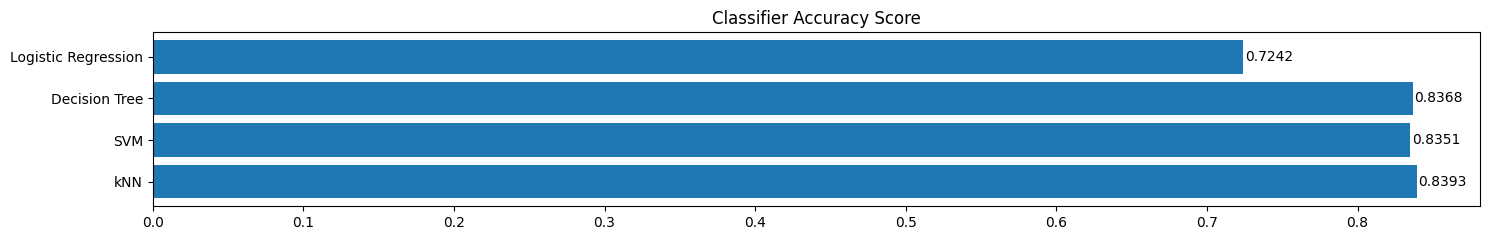

In [28]:
# 네 가지 단일 모델의 정확도를 가로 막대 차트로 비교

model_name = ['Logistic Regression', 'Decision Tree', 'SVM', 'kNN']
accuracy_scores = [lr_accuracy, tree_accuracy, svm_accuracy, knn_accuracy]

plt.figure(figsize=(15, 2.5))
bars = plt.barh(model_name[::-1], accuracy_scores[::-1])

for bar, accuracy in zip(bars, accuracy_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f'{accuracy:.4f}', va='center')

plt.title("Classifier Accuracy Score")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 앙상블 (Ensemble)

### 1. Voting

Voting은 단어 뜻 그대로 **투표를 통해 결정하는 방식**입니다. Voting은 Bagging과 투표방식이라는 점에서 유사하지만, 다음과 같은 큰 차이점이 있습니다.

- **Voting**: 서로 **다른 알고리즘** 모델들을 조합해 사용합니다.
- **Bagging**: **같은 알고리즘** 내에서 다른 샘플 조합을 사용합니다.

**Hard Voting vs Soft Voting**
| 방식 | 설명 | 예시 |
|------|------|------|
| Hard Voting | 각 모델의 예측 클래스를 다수결로 결정 | [1, 0, 1] → 1 |
| Soft Voting | 각 모델의 확률 평균으로 결정 (더 정확한 경향) | [0.7, 0.4, 0.8] → 평균 0.63 → 1 |


`VotingClassifier`

- **estimators**: 사용할 기본 분류기 리스트 (이름, 모델) 형태로 지정
- **voting**: 'hard' 또는 'soft' (기본값: 'hard')
- **weights**: 각 분류기별 가중치
- **n_jobs**: 병렬 처리 수

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html)

In [ ]:
# VotingClassifier에 넣을 기본 분류기 목록
# (이름, 모델인스턴스) 튜플 형식으로 지정
# 서로 다른 알고리즘을 사용해 각 모델의 장점을 살림

models = [
    ('lr', LogisticRegression(random_state=SEED)),    # 선형 경계
    ('dt', DecisionTreeClassifier(random_state=SEED)), # 비선형 트리
    ('rf', RandomForestClassifier(random_state=SEED))  # 앙상블 트리
]

In [ ]:
# Hard Voting: 세 모델이 각각 예측한 뒤 다수결로 최종 클래스 결정
# ex) LR→1, DT→0, RF→1 이면 → 최종 예측: 1

voting_clf = ***(estimators=***, voting='****')

voting_clf.fit(X_train, y_train)
y_voting_pred = voting_clf.predict(X_test)
print(f"Voting Accuracy: {accuracy_score(y_test, y_voting_pred):.4f}")

Voting Accuracy: 0.8505


### 2. Bagging

Bootstrap + Aggregating   
1. 부트스트랩을 통해 전체 데이터셋에서 중복을 허용하여 무작위로 재표본 추출을 하고,
2. 동일한 알고리즘 모델을 사용해 각각의 샘플을 독립적으로 학습하고,
3. 모든 모델의 예측값을 결합해 최종 결과를 도출하는 방법입니다.

`RandomForestClassifier`

- **n_estimators**: 트리 개수
- **max_depth**: 트리 최대 깊이
- **max_features**: 노드 분할 시 고려할 특성 수
- **min_samples_split**: 노드 분할에 필요한 최소 샘플 수
- **bootstrap**: 부트스트랩 여부 (기본값: True)

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [ ]:
# 랜덤 포레스트 (배깅의 대표 모델)
# 부트스트랩 샘플링으로 만든 여러 결정 트리를 학습하고, 다수결로 최종 예측
# 개별 트리보다 과대적합에 강하고 안정적인 성능을 보임
# n_estimators 기본값: 100 (트리 100개 사용)

rf_clf = ***(random_state=SEED)
rf_clf.fit(X_train, y_train)
y_rf_pred = rf_clf.predict(X_test)
print(f"Bagging (Random Forest) Accuracy: {accuracy_score(y_test, y_rf_pred):.4f}")

Bagging (Random Forest) Accuracy: 0.8514


#### Q. Decision Tree(0.8368)와 Random Forest(0.8514)의 성능을 비교했을 때 Random Forest가 더 좋은 성능을 보였습니다. 그 이유를 설명해주세요.
#### A. 
<br>

### 3. Boosting

약한 학습기를 순차적으로 학습을 하되, 이전 학습에 대하여 잘못 예측된 데이터에 **가중치를 부여해 오차를 보완**해 나가는 방식입니다.

**장점** 
- 성능이 매우 우수합니다. (Lgbm, XGBoost 등)

**단점**
- 부스팅 알고리즘의 특성상 계속 약점(오분류/잔차)을 보완하려고 하기 때문에 **잘못된 레이블링이나 아웃라이어에 필요 이상으로 민감**할 수 있습니다.
- 순차적이기 때문에 병렬처리에 어려움이 있고, 그렇다보니 **학습 시간이 오래 걸립니다.**.

#### 3.1 AdaBoost

- 가장 초기 모델  
- 요즘 잘 안씀

`AdaBoostClassifier`

- **estimator**: 기본 약한 학습기
- **n_estimators**: 학습기 개수
- **learning_rate**: 학습률

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

In [ ]:
# AdaBoost: 가장 초기의 부스팅 알고리즘
# 매 반복마다 이전 모델이 틀린 샘플에 더 높은 가중치를 부여해 다음 모델이 집중 학습
# 최종 예측은 각 약한 학습기(weak learner)의 가중 합산으로 결정

adaboost = ***(random_state=SEED)
adaboost.fit(X_train, y_train)
y_ada_pred = adaboost.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_ada_pred):.4f}")

AdaBoost Accuracy: 0.8230


#### 3.2 GBM

- 성능이 우수함
- 학습시간이 해도해도 너무 느림

`GradientBoostingClassifier`

- **n_estimators**: 부스팅 단계 수
- **learning_rate**: 각 단계의 기여도
- **max_depth**: 개별 트리의 최대 깊이
- **subsample**: 학습 데이터 샘플 비율
- **min_samples_split**: 노드 분할 최소 샘플 수
- **loss**: 손실 함수 ('log_loss', 'exponential')

[Docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html)

In [ ]:
# GBM(Gradient Boosting Machine): 잔차(residual)를 순차적으로 학습
# 이전 모델의 예측 오차(잔차)를 다음 트리가 학습하는 방식으로 점진적으로 개선
# 성능이 매우 우수하지만, 순차 학습 특성상 속도가 느림 (병렬 처리 불가)

gbm = ***(random_state=SEED)
gbm.fit(X_train, y_train)
y_gbm_pred = gbm.predict(X_test)
print(f"GBM Accuracy: {accuracy_score(y_test, y_gbm_pred):.4f}")

GBM Accuracy: 0.8660


#### 3.3 XGBoost

- scikit-learn 패키지 X
- GBM보다는 빠르고 성능도 향상됨
- 그러나 여전히 학습시간이 느림
- 대신 정확도가 굉장히 높아 대회에서 사용함

`XGBClassifier`

- **n_estimators**: 부스팅 반복 횟수
- **learning_rate**: 학습률
- **max_depth**: 트리 깊이
- **subsample**: 샘플 비율
- **colsample_bytree**: 트리당 특성 샘플 비율
- **gamma**: 분할 최소 손실 감소
- **objective**: 목적 함수 ('multi:softprob', 'binary:logistic' 등)
- **eval_metric**: 평가 지표 ('mlogloss', 'logloss', 'error' 등)

[Docs](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier)

In [ ]:
# XGBoost: GBM의 속도·성능을 대폭 개선한 부스팅 라이브러리
# GBM과 달리 병렬 처리·캐시 최적화·정규화(L1/L2)를 지원해 속도와 과적합 방지 모두 개선
# 캐글(Kaggle) 등 데이터 대회에서 널리 사용됨

xgboost = xgb.***(random_state=SEED)
xgboost.fit(X_train, y_train)
y_xgb_pred = xgboost.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_xgb_pred):.4f}")

XGBoost Accuracy: 0.8608


#### 3.4 LightGBM

- scikit-learn 패키지 X (Microsoft사 개발)
- 성능이 우수함
- 기존 부스팅 계열 알고리즘이 가지는 단점인 **느린 학습 속도를 개선**함

`LGBMClassifier`

- **n_estimators**: 트리 개수
- **learning_rate**: 학습률
- **max_depth**: 최대 깊이 (기본: -1 → 제한 없음)
- **num_leaves**: 리프 노드 수
- **subsample**: 데이터 샘플 비율
- **colsample_bytree**: 트리당 특성 샘플 비율
- **min_child_samples**: 리프 노드의 최소 샘플 수
- **objective**: 'binary', 'multiclass' 등

[Docs](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html)

In [ ]:
# LightGBM: Microsoft 개발, 기존 GBM 계열의 느린 속도를 크게 개선
# 핵심 차이: Leaf-wise 트리 성장 (기존 GBM은 Level-wise)
#   → 같은 연산량으로 손실을 더 크게 줄여 빠르고 높은 성능 달성

lgbm = lgb.***(random_state=SEED, verbose=-1)
lgbm.fit(X_train, y_train)
y_lgbm_pred = lgbm.predict(X_test)
print(f"LightGBM Accuracy: {accuracy_score(y_test, y_lgbm_pred):.4f}")

LightGBM Accuracy: 0.8686


#### 3.5 CatBoost

`CatBoostClassifier`

- **iterations**: 부스팅 반복 횟수
- **learning_rate**: 학습률
- **depth**: 트리 깊이
- **l2_leaf_reg**: L2 정규화 계수
- **loss_function**: 손실 함수 (예: 'Logloss', 'MultiClass')
- **random_state**: 랜덤 시드
- **verbose**: 출력 제어 (0: 진행 메시지 표시하지 않음, 100: 진행률 표시)

[Docs](https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier)

In [ ]:
# CatBoost: Yandex 개발, 범주형 변수를 별도 인코딩 없이 자동으로 처리하는 부스팅 모델
# 범주형 피처가 많은 데이터에서 특히 강점을 가짐
# depth=10: 트리 최대 깊이 (기본값 6보다 깊게 설정 → 더 복잡한 패턴 학습)

cb = ***(random_state=SEED, depth=10, verbose=0)
cb.fit(X_train, y_train)
y_cb_pred = cb.predict(X_test)
print(f"CatBoost Accuracy: {accuracy_score(y_test, y_cb_pred):.4f}")

CatBoost Accuracy: 0.8600


### 4. Stacking

개별 모델이 예측한 데이터를 기반으로 **final_estimator**가 종합하여 최종 예측을 수행합니다.

**동작 원리**
1. 훈련 데이터를 k-fold로 나눠 각 base 모델을 학습
2. base 모델들이 예측한 결과를 새로운 피처로 만들어 메타 데이터셋 구성
3. 메타 모델(final_estimator)이 메타 데이터셋을 학습해 최종 예측

> 💡 성능을 극한까지 끌어올릴 때 사용하지만, 과대적합 위험이 있고 학습 시간이 매우 깁니다.


In [ ]:
# base_learners: 1단계에서 각자 예측값을 생성할 모델들
# 서로 다른 알고리즘을 사용해 다양한 관점의 예측값을 확보
base_learners = [
    ('lr', LogisticRegression(random_state=SEED)),
    ('dt', DecisionTreeClassifier(random_state=SEED)),
    ('rf', RandomForestClassifier(random_state=SEED))
]

stack_clf = ***(
    estimators=base_learners,
    final_estimator=LogisticRegression(random_state=SEED),  # 2단계: 메타 모델
    cv=5  # 5-fold 교차검증으로 메타 데이터셋 생성 (데이터 누수 방지)
)

stack_clf.fit(X_train, y_train)
y_stk_pred = stack_clf.predict(X_test)
print(f"Stacking Accuracy: {accuracy_score(y_test, y_stk_pred):.4f}")

Stacking Accuracy: 0.8514


### 과제에서 다룬 모든 모델들의 성능을 시각화로 비교해봅시다!

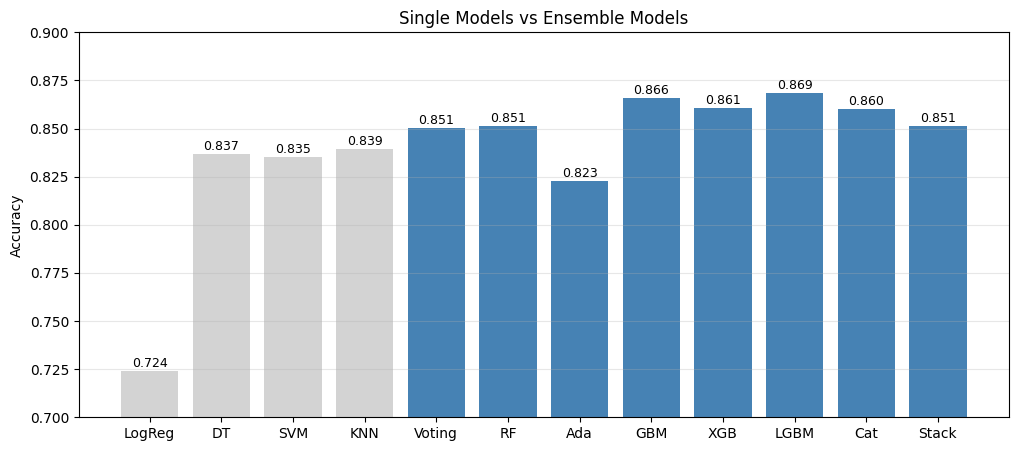

In [1]:
import matplotlib.pyplot as plt

models = [
    'LogReg','DT','SVM','KNN',
    'Voting','RF','Ada','GBM',
    'XGB','LGBM','Cat','Stack'
]

accuracy = [
    0.7242,
    0.8368,
    0.8351,
    0.8393,
    0.8505,
    0.8514,
    0.8230,
    0.8660,
    0.8608,
    0.8686,
    0.8600,
    0.8514
]

# 단일 모델=회색, 앙상블=파란색
colors = [
    'lightgray','lightgray','lightgray','lightgray',
    'steelblue','steelblue','steelblue','steelblue',
    'steelblue','steelblue','steelblue','steelblue'
]

plt.figure(figsize=(12,5))
bars = plt.bar(models, accuracy, color=colors)

plt.ylim(0.70, 0.90)
plt.ylabel("Accuracy")
plt.title("Single Models vs Ensemble Models")

for bar, score in zip(bars, accuracy):
    plt.text(bar.get_x()+bar.get_width()/2,
             score+0.002,
             f"{score:.3f}",
             ha='center',
             fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.show()

#### Q. 이번 실습 결과만 놓고 보면 "앙상블 모델은 항상 단일 모델보다 성능이 좋다."라고 결론 내릴 수 있을까요?
##### A. 

## 앙상블 모델을 정리하며

1. 앙상블은 대체적으로 단일 모델 대비 성능이 좋습니다.
2. 앙상블을 앙상블하는 기법인 Stacking도 참고해볼만 합니다.
3. 앙상블 모델은 적절한 **Hyperparameter 튜닝**이 중요합니다.
4. 앙상블 모델은 대체적으로 학습시간이 더 오래 걸립니다.
5. 따라서, 모델 튜닝을 하는 데에 걸리는 시간도 오래 소요됩니다.

수고하셨습니다~~  
앞으로의 심화 세션도 빠이띵~~~